## Chapter 3: Creating a ROS 2 Topics

### Introduction
In ROS 2, nodes need a way to exchange data. The most common and fundamental communication method is the Topic. Topics are primarily used for continuous data streams, such as sensor readings (e.g., battery managment system (BMS), laser scans, camera frames) or continuous control commands (e.g., velocity commands to motors).

What is a ROS Topic?
1. A ROS Topic implements a Publisher/Subscriber architecture.
2. Publisher: A node that sends data to a specific topic name.
3. Subscriber: A node that listens to a specific topic name to receive data.
4. Decoupling: Publishers and subscribers do not know about each other's existence. A node simply broadcasts data to a topic, and any number of nodes can subscribe to that topic to read the data. This allows for a highly modular and decoupled system (one-to-many, many-to-one, or many-to-many communication).

### Battery Status Topic
Now we will modify our node to add this functionality to our *battery_status* node. This will add a topic where we will write the robot's battery level. So we will publish this information to the topic: /battery_status.

Our code now let us know that the battery is handled and now it subscribes to the battery topic the battery information. Copy and paste this into battery_status.py.

In [ ]:
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
from std_msgs.msg import String

class BatteryStatus(Node):
    def __init__(self):
        
        super().__init__('battery_status_node')
        
        
        self.get_logger().info("Battery monitoring node is running. Checking battery status.")

        # creation of the subsciption to the /battery_status topic
        self.subscription = self.create_subscription(
            String,
            '/battery_status',
            self.listener_callback,
            10)
        self.subscription

    def listener_callback(self, msg):
        self.get_logger().info(f'Received battery update: "{msg.data}"')

def main(args=None):
    rclpy.init(args=args)           
    node = BatteryStatus()            
    
    
    rclpy.spin(node)            
    
    
    node.destroy_node()             
    rclpy.shutdown()                

if __name__ == '__main__':
    main()

But the subscriber just hear what is inside the topic, to publish a message we need a publisher.

To test the subscriber, firstly, we do not strictly need a publisher node. We can use the CLI (Command Line Interface) tool ROS 2 topic publisher to manually inject data into the system, faking a battery sensor.

But first, we must compile and source the workspace:

In [ ]:
!cd ~/ros2_ws2

!colcon build --packages-select amrj16_battery_management --symlink-install

!source install/setup.bash

Once all is ready we start our node just as before:

In [ ]:
!ros2 launch amrj16_battery_management bms_node.launch.py

And the output will be something like this:

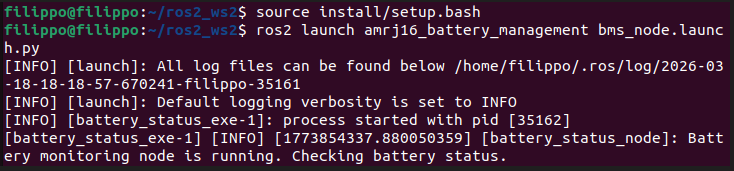

As you can see the robot says *'Battery monitoring node is running. Checking battery status.'* and than stops, this means that the robot is listening into a topic which is empty for now.

if we publish the information of the battery with this command:

In [ ]:
# open a new terminal

#source the environment
!source install/setup.bash

# publish the message
!ros2 topic pub /battery_status std_msgs/msg/String "{data: 'Battery at 85%'}"

The node takes live printing the information recived by the battery:

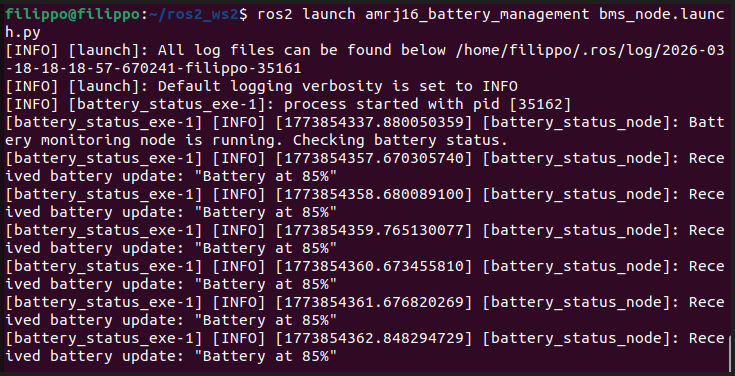

This was just an example on how the subscriber works, now we need to develop a node that have inside the battery sensor whihc publish some battery parameters information.

into the amrj16_battery_management folder create a new file called bms_pub_info.py:

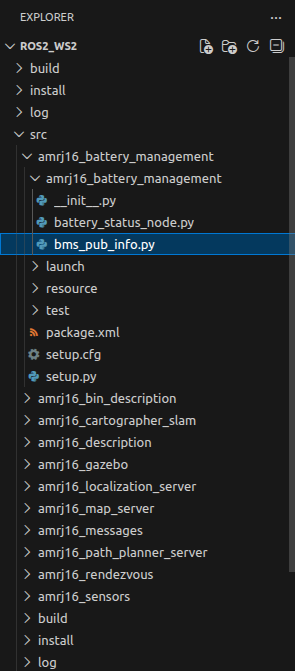

Inside this file paste this code:

In [ ]:
import rclpy
from rclpy.node import Node
from std_msgs.msg import String

class BatteryPublisher(Node):
    def __init__(self):
        super().__init__('battery_publisher_node')
        
        self.publisher_ = self.create_publisher(String, '/battery_status', 10)
        
        timer_period = 1.0  
        self.timer = self.create_timer(timer_period, self.timer_callback)
        self.battery_level = 100

    def timer_callback(self):
        
        # Create the message object
        msg = String()
        msg.data = f'Battery Level: {self.battery_level}%'
        
        # Publish the message
        self.publisher_.publish(msg)
        self.get_logger().info(f'Publishing: "{msg.data}"')
        
        # Simulate battery drain
        if self.battery_level > 0:
            self.battery_level -= 1

def main(args=None):
    rclpy.init(args=args)
    node = BatteryPublisher()
    rclpy.spin(node)
    node.destroy_node()
    rclpy.shutdown()

if __name__ == '__main__':
    main()

Remember to register this new executable inside the setup.py file

In [ ]:
import os
from glob import glob
from setuptools import find_packages, setup

package_name = 'amrj16_battery_management'

setup(
    name=package_name,
    version='0.0.0',
    packages=find_packages(exclude=['test']),
    data_files=[
        ('share/ament_index/resource_index/packages',
            ['resource/' + package_name]),
        ('share/' + package_name, ['package.xml']),
        (os.path.join('share', package_name, 'launch'), glob('launch/*.launch.py')),
    ],
    install_requires=['setuptools'],
    zip_safe=True,
    maintainer='you',
    maintainer_email='',
    description='TODO: Package description',
    license='TODO: License declaration',
    extras_require={
        'test': [
            'pytest',
        ],
    },
    entry_points={
        'console_scripts': [
            'battery_status_exe = amrj16_battery_management.battery_status:main',
            'bms_pub_info_exe = amrj16_battery_management.bms_pub_info:main'  # NEW LINE
        ],
    },
)

Remeber to compile and source the environment.

The output is:

missing video


As we can see the publisher is publishing the battery information while the battery is discharging and the subscriber is reciving the informaiton. The system is syncronized and in real time, just like real battery sensor which publish its informaiton into the network, with this information we listen to it and we proces in our subscriber node.


### How to mix publisher and subscriber.

Now we just explore the basic fundation of how the information flow in ROS 2 but in real robotic application the recived information are always used to publish other information, and a single node usually has a mixture of subscriber and publisher. Now we will create a basic node containig both.

Precisely, our code will read the information from the battery_status topic and publish an alert if the battery level falls below a safety threshold on a new topic called /safety_alert.

Now create a new file called battery_monitor.py in the amrj16_battery_management folder and paste this code:

In [ ]:
#!/usr/bin/env python3

import rclpy
from rclpy.node import Node
from std_msgs.msg import Float32
from std_msgs.msg import String

class BatteryMonitor(Node):
    def __init__(self):
        super().__init__('battery_monitor_node')
        
        # create Subscriber
        self.subscription = self.create_subscription(
            Float32,
            '/battery_status',
            self.battery_callback,
            10)
            
        #create Publisher
        self.publisher_ = self.create_publisher(String, '/safety_alert', 10)

    def battery_callback(self, msg):
        self.get_logger().info(f'Monitor received: "{msg.data}"')

        if(msg.data < 80.0):
            alert_msg = String()
            alert_msg.data = f"[WARNING] battery Low: {msg.data}%"
            self.publisher_.publish(alert_msg)

def main(args=None):
    rclpy.init(args=args)
    node = BatteryMonitor()
    rclpy.spin(node)
    node.destroy_node()
    rclpy.shutdown()

if __name__ == '__main__':
    main()

Update also the setup.py in this way:

In [ ]:
import os
from glob import glob
from setuptools import find_packages, setup

package_name = 'amrj16_battery_management'

setup(
    name=package_name,
    version='0.0.0',
    packages=find_packages(exclude=['test']),
    data_files=[
        ('share/ament_index/resource_index/packages',
            ['resource/' + package_name]),
        ('share/' + package_name, ['package.xml']),
        (os.path.join('share', package_name, 'launch'), glob('launch/*.launch.py')),
    ],
    install_requires=['setuptools'],
    zip_safe=True,
    maintainer='you',
    maintainer_email='',
    description='TODO: Package description',
    license='TODO: License declaration',
    extras_require={
        'test': [
            'pytest',
        ],
    },
    entry_points={
        'console_scripts': [
            'battery_status_exe = amrj16_battery_management.battery_status:main',
            'bms_pub_info_exe = amrj16_battery_management.bms_pub_info:main',
            'battery_monitor_exe = amrj16_battery_management.battery_monitor:main'   # NEW LINE
        ],
    },
)

Compile and source.

Then run all this three command in three different terminal windows:

In [ ]:
!ros2 run amrj16_battery_management battery_monitor_exe

!ros2 run amrj16_battery_management bms_pub_info_exe

!ros2 topic echo /safety_alert

You will see this:

missin video

As we can see the system is working just like before, but this time when the battery goes below the 80% the system publish a message in the safety_alert topic informing us with the critical situation. This is very usefull in robotics because when we recive this critical message we can, for example, direct the robot to the nearest charging station and start the docking.

### Create a custom Interface for topics

Sometimes the standard available messages in ROS 2 is not enough detailed for a custom pourpose, to overcome this ROS 2 allow to create a custom interface in order to create exactly what someone needs.

For this example we will create an interface that gives us the information about the battery but also its temperature which in some cases could affect the battery duration, and instead of publish this information into two topic we will have this interface called /battery_status which contains both the parameters.

In ROS 2, custom interfaces (.msg, .srv, .action) should ideally be placed in a dedicated ament_cmake package. Even if your logic nodes are written in Python, the message generation system relies on CMake.

Fortunally, the repository we created previously has already a folder for storing this custom interfaces and its called amrj16_messages

In [ ]:
# this are the steps if this directory is missing

# return to teh workspace src folder
!cd ~/ros2_ws2/src

# Create a C++ (ament_cmake) package for the messages
!ros2 pkg create --build-type ament_cmake robot_status_msgs

# Create the msg directory
!mkdir -p robot_status_msgs/msg

Once created the folder we need to create the file.msg and copy and paste this:

In [ ]:
int8 charge_percentage
float32 temperature

The final structure must be this:

Look cearfully at the left side for the folder structure and in the right side for the content of the file.

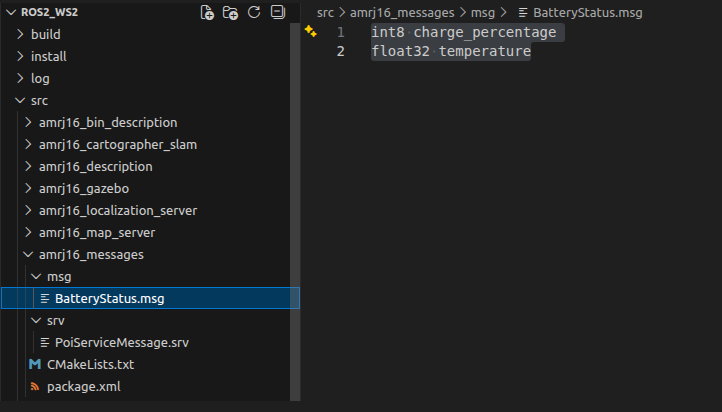

Once obtained this result we need to compile the message by updating the CMakeList.txt and the package.xml of the amrj16_messages pkg.

The CMakeList.txt file is:

In [ ]:
cmake_minimum_required(VERSION 3.8)
project(amrj16_messages)

if(CMAKE_COMPILER_IS_GNUCXX OR CMAKE_CXX_COMPILER_ID MATCHES "Clang")
  add_compile_options(-Wall -Wextra -Wpedantic)
endif()

# find dependencies
find_package(ament_cmake REQUIRED)
find_package(rclcpp REQUIRED)
find_package(std_msgs REQUIRED)
find_package(rosidl_default_generators REQUIRED)   # IMPORTANT LINE TO USE CUSTOM INTERFACE, ALREADY PRESENT


if(BUILD_TESTING)
  find_package(ament_lint_auto REQUIRED)
  # the following line skips the linter which checks for copyrights
  # uncomment the line when a copyright and license is not present in all source files
  #set(ament_cmake_copyright_FOUND TRUE)
  # the following line skips cpplint (only works in a git repo)
  # uncomment the line when this package is not in a git repo
  #set(ament_cmake_cpplint_FOUND TRUE)
  ament_lint_auto_find_test_dependencies()
endif()

rosidl_generate_interfaces(${PROJECT_NAME}
  "srv/PoiServiceMessage.srv"
  "msg/BatteryStatus.msg"  #NEW LINE
)


ament_package()


And the package.xml is:

In [ ]:
<?xml version="1.0"?>
<?xml-model href="http://download.ros.org/schema/package_format3.xsd" schematypens="http://www.w3.org/2001/XMLSchema"?>
<package format="3">
  <name>amrj16_messages</name>
  <version>0.0.0</version>
  <description>TODO: Package description</description>
  <maintainer email="user@todo.todo">user</maintainer>
  <license>TODO: License declaration</license>

  <buildtool_depend>ament_cmake</buildtool_depend>

  <depend>rclcpp</depend>
  <depend>std_msgs</depend>

  <build_depend>rosidl_default_generators</build_depend>
  <exec_depend>rosidl_default_runtime</exec_depend>
  <member_of_group>rosidl_interface_packages</member_of_group>

  <test_depend>ament_lint_auto</test_depend>
  <test_depend>ament_lint_common</test_depend>

  <export>
    <build_type>ament_cmake</build_type>
  </export>
</package>

now we need to compile and source the environment:

In [ ]:

!cd ~/ros2_ws2

!colcon build --packages-select amrj16_messages

!source install/setup.bash

To check if everything goes well this is the command:

In [ ]:
!ros2 interface show amrj16_messages/msg/BatteryStatus

And the output is:

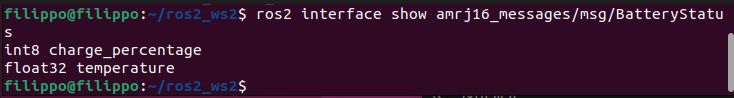

exactly what we have written in our custom interface.

To use it we just import it like any other python module.

Now we will create a new advanced_batter_pub.py node:

In [ ]:
import rclpy
from rclpy.node import Node

# Import our brand new custom message!
from amrj16_messages.msg import BatteryStatus    #NEW LINE

class AdvancedBatteryPub(Node):
    def __init__(self):
        super().__init__('advanced_battery_publisher')
        
        # Publisher using the custom BatteryStatus type
        self.publisher_ = self.create_publisher(BatteryStatus, '/hardware/battery', 10)
        self.timer = self.create_timer(1.0, self.timer_callback)

    def timer_callback(self):
        msg = BatteryStatus()
        # Populate the structured fields
        msg.temperature = 35.2
        msg.charge_percentage = 88
        
        self.publisher_.publish(msg)
        self.get_logger().info(f'Published Battery Data: {msg.charge_percentage}% at {msg.temperature} Celsius')

def main(args=None):
    rclpy.init(args=args)
    node = AdvancedBatteryPub()
    rclpy.spin(node)
    node.destroy_node()
    rclpy.shutdown()

if __name__ == '__main__':
    main()

Now compile the package and source the environment:

In [ ]:
!colcon build --packages-select robot_status

!source install/setup.bash

#run the new node:
!ros2 run amrj16_battery_management advanced_battery_pub_exe

#in another terminal:

!source install/setup.bash

#listen what is inside this topic
ros2 topic echo /battery_status

this is the output: 

missing video

Of course you can insert this into a node such as battery monitor and puiblish reaction or warning messages depending on the info recived with this custom interfaces.